# Clase 7 · Cartera mixta en riesgo, CML y CAPM

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/prof-rodolfo-medina/modelizacion-derivados-carteras/blob/main/sesiones/semana-07/clase-07-cartera-mixta-capm.ipynb)

**Semana 7 (14–18/12/2026) · Tema 10 · 90 min (incluye resolución de la Actividad 2)**

Objetivos:
1. Construir carteras mixtas (activo libre de riesgo + activos con riesgo) y la Recta del Mercado Capital.
2. Calcular la Cartera del Mercado (tangente) para distintas tasas libres de riesgo.
3. Estimar betas y usar la Recta de Seguridad del Mercado (SML).

In [1]:
# Configuración: funciona en local (repositorio clonado) y en Google Colab
import sys, subprocess, pathlib
try:
    import mvdc
except ImportError:
    if "google.colab" in sys.modules:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                        "git+https://github.com/prof-rodolfo-medina/modelizacion-derivados-carteras.git"], check=True)
    else:
        for base in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
            if (base / "src" / "mvdc").exists():
                sys.path.insert(0, str(base / "src"))
                break
    import mvdc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (8, 4.5), "axes.grid": True, "grid.alpha": 0.3})
print("mvdc", mvdc.__version__)

mvdc 2026.11


## 1. Cartera del Mercado Capital (Teorema 1 del Tema 10)

$$w^*=\frac{(m-\mu_{rf}\mathbf 1)C^{-1}}{(m-\mu_{rf}\mathbf 1)C^{-1}\mathbf 1^\top}$$

In [2]:
from mvdc import portfolio as pf

m = np.array([0.3, 0.2, 0.5])
C = pf.cov_from_corr([0.15, 0.02, 0.3], [[1, -0.07, 0.02], [-0.07, 1, 0.2], [0.02, 0.2, 1]])
filas = []
for rf in [0.01, 0.02, 0.03]:          # Ejemplo 1 y Ejercicio 1 del tema
    w = pf.tangency_weights(m, C, rf)
    mu_M, s_M = pf.portfolio_stats(w, m, C)
    filas.append({"μ_rf": rf, "w1": w[0], "w2": w[1], "w3": w[2], "μ_M": mu_M, "σ_M": s_M,
                  "Sharpe": (mu_M - rf) / s_M})
pd.DataFrame(filas).round(5)

,μ_rf,w1,w2,w3,μ_M,σ_M,Sharpe
0,0.01,0.03470,0.96775,-0.00245,0.20273,0.01955,9.85730
1,0.02,0.03516,0.96691,-0.00208,0.20289,0.01957,9.34607
2,0.03,0.03569,0.96597,-0.00166,0.20307,0.01959,8.83530


## 2. CML y carteras mixtas

w_risky = 0.25 → (σ, μ) = (0.0049, 0.0582)   
w_risky = 0.50 → (σ, μ) = (0.0098, 0.1064)   
w_risky = 1.00 → (σ, μ) = (0.0196, 0.2027)   
w_risky = 1.50 → (σ, μ) = (0.0293, 0.2991)   (apalancada: w_rf < 0)


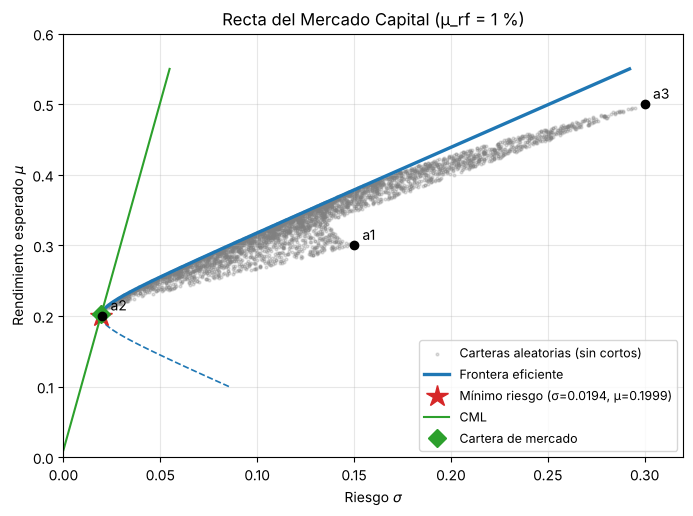

In [3]:
ax = pf.plot_frontier(m, C, mu_range=(0.1, 0.55), mu_rf=0.01, asset_labels=["a1", "a2", "a3"])
ax.set_xlim(0, 0.32); ax.set_ylim(0, 0.6); ax.set_title("Recta del Mercado Capital (μ_rf = 1 %)");

w = pf.tangency_weights(m, C, 0.01); mu_M, s_M = pf.portfolio_stats(w, m, C)
for wr in [0.25, 0.5, 1.0, 1.5]:
    s, mu = pf.mixed_portfolio(wr, 0.01, mu_M, s_M)
    print(f"w_risky = {wr:4.2f} → (σ, μ) = ({s:.4f}, {mu:.4f})   {'(apalancada: w_rf < 0)' if wr > 1 else ''}")

## 3. Beta y Recta de Seguridad del Mercado con datos simulados

,β estimada,μ histórica,μ según SML
activo,,,
AK1,0.6172,0.0501,0.0756
AK2,1.0229,0.1882,0.1056
AK3,1.3366,0.2091,0.1288
AK4,-0.2300,0.2512,0.0130


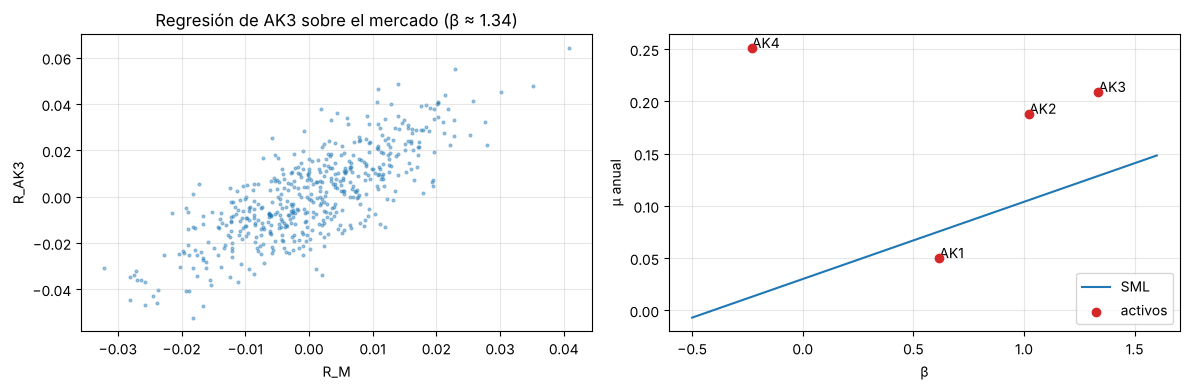

In [4]:
niveles = mvdc.datos.cargar("mercado_simulado.csv")
R = pf.log_returns(niveles)
mu_M_hist = R["MERCADO"].mean() * 252
rf = 0.03
res = []
for k in ["AK1", "AK2", "AK3", "AK4"]:
    bk = pf.beta(R[k], R["MERCADO"])
    res.append({"activo": k, "β estimada": bk, "μ histórica": R[k].mean() * 252,
                "μ según SML": pf.security_market_line(bk, mu_M_hist, rf)})
tab = pd.DataFrame(res).set_index("activo"); display(tab.round(4))

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].scatter(R["MERCADO"], R["AK3"], s=4, alpha=0.4); axs[0].set_xlabel("R_M"); axs[0].set_ylabel("R_AK3")
axs[0].set_title(f"Regresión de AK3 sobre el mercado (β ≈ {tab.loc['AK3', 'β estimada']:.2f})")
bb = np.linspace(-0.5, 1.6, 50)
axs[1].plot(bb, pf.security_market_line(bb, mu_M_hist, rf), label="SML")
axs[1].scatter(tab["β estimada"], tab["μ histórica"], color="C3", zorder=5, label="activos")
for k, r_ in tab.iterrows(): axs[1].annotate(k, (r_["β estimada"], r_["μ histórica"]))
axs[1].set_xlabel("β"); axs[1].set_ylabel("μ anual"); axs[1].legend(); plt.tight_layout()

**Discusión.** Los puntos no caen exactamente sobre la SML: ¿por qué? (ruido de estimación de
la media en 2 años, riesgo no sistemático $V(\varepsilon)$...).

## 4. Ejercicio en clase — Ejemplo 2 del Tema 10

Con $\mu_{rf}=3\%$ y $\mu_M = 12\%$, calcula $\mu_K$ para $\beta = (0.65,\,1,\,1.2,\,-0.2,\,-0.6)$.
Compara el último valor con el de los apuntes (ver `docs/erratas-temario.md`).

In [5]:
# Tu código aquí

## 5. Resolución de la Actividad 2

Se revisa en la sesión tras la fecha de entrega (14/12/2026): carga de datos, estadísticos,
pesos de mínimo riesgo, frontera eficiente y análisis financiero según la rúbrica.